In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense, BatchNormalization
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, roc_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# tree-based models
x_train = pd.read_csv('../data/processed/x_train.csv')
x_cv = pd.read_csv('../data/processed/x_cv.csv')
x_test = pd.read_csv('../data/processed/x_test.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_cv = pd.read_csv('../data/processed/y_cv.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# logistic regression and neural networks
x_train_scaled = pd.read_csv('../data/processed/x_train_scaled.csv')
x_cv_scaled = pd.read_csv('../data/processed/x_cv_scaled.csv')
x_test_scaled = pd.read_csv('../data/processed/x_test_scaled.csv')

cs_test = pd.read_csv('../data/processed/cs_test_processed.csv')
cs_test_scaled = pd.read_csv('../data/processed/cs_test_scaled.csv')

# for GridSearchCV and RandomizedSearchCV use x_train + x_cv
x_train_full = np.concatenate((x_train, x_cv), axis=0)
x_train_sc_full = np.concatenate((x_train_scaled, x_cv_scaled), axis=0)
y_train_full = np.concatenate((y_train, y_cv), axis=0)

In [3]:
scores = []

In [4]:
def build_search_cv(param_grid, model, x_train, y_train):
    if isinstance(model, (XGBClassifier, RandomForestClassifier)):
        grid = RandomizedSearchCV(model, param_grid, scoring=['roc_auc', 'f1'], refit='roc_auc', n_jobs=6, random_state=42)
    else:
        grid = GridSearchCV(model, param_grid, scoring=['roc_auc', 'f1'], refit='roc_auc')

    grid.fit(x_train, y_train)
    
    best_idx = grid.best_index_
    best_f1 = grid.cv_results_['mean_test_f1'][best_idx]

    print(grid.best_params_, grid.best_score_, 'F1:', best_f1)

    best_model = grid.best_estimator_
    scores.append({'model_name': type(model).__name__, 'roc_auc': grid.best_score_, 'f1': best_f1})

    return best_model

In [5]:
lr_params = {'solver': ['liblinear', 'lbfgs', 'sag']}
lr_model = build_search_cv(lr_params, LogisticRegression(max_iter=1000, random_state=42), x_train_sc_full, y_train_full)

{'solver': 'liblinear'} 0.8390251932699518 F1: 0.22046174859075301


In [6]:
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 7, 10, 15]}
dt_model = build_search_cv(dt_params, DecisionTreeClassifier(random_state=42), x_train_full, y_train_full)

{'max_depth': 5, 'min_samples_split': 2} 0.8474094770266062 F1: 0.2628740244379327


In [7]:
rf_params = {'n_estimators': [100, 200, 400], 'max_depth': [5, 10, 12, 20], 'min_samples_split':[2, 5, 10, 15]}
rf_model = build_search_cv(rf_params, RandomForestClassifier(random_state=42, n_jobs=1), x_train_full, y_train_full)

{'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10} 0.8630922169359956 F1: 0.2525128616227197


In [8]:
xgbc_params = {'n_estimators': [100, 200, 400, 700], 'learning_rate': [0.01, 0.03, 0.05], 'max_depth': [5, 10, 12, 20]}
xgbc_model = build_search_cv(xgbc_params, XGBClassifier(random_state=42, n_jobs=1), x_train_full, y_train_full)

{'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.03} 0.8651967907001019 F1: 0.2925199516640578


In [9]:
def build_models():
    model_1 = Sequential([
        Dense(units=25, activation='relu'),
        Dense(units=15, activation='relu'),
        Dense(units=1, activation='linear'),
    ], name='model_1')

    model_2 = Sequential([
        Dense(units=30, activation='relu'),
        Dense(units=12, activation='relu'),
        Dense(units=7, activation='relu'),
        Dense(units=1, activation='linear'),
    ], name='model_2')

    model_3 = Sequential([
        Dense(units=32, activation='relu'),
        BatchNormalization(),
        Dense(units=16, activation='relu'),
        BatchNormalization(),
        Dense(units=8, activation='relu'),
        BatchNormalization(),
        Dense(units=12, activation='relu'),
        BatchNormalization(),
        Dense(units=1, activation='linear'),
    ], name='model_3')

    models = [model_1, model_2, model_3]
    return models

In [10]:
models_nn = build_models()

early_stop = EarlyStopping(
    monitor='val_AUC',      
    patience=20,            
    restore_best_weights=True,  
    mode='max'               
)

histories = {}

for model in models_nn:
    model.compile(
        loss=BinaryCrossentropy(from_logits=True),
        optimizer=Adam(learning_rate=0.01),
        metrics=['AUC'] 
    )

    history = model.fit(
        x_train_scaled, y_train,      
        validation_data=(x_cv_scaled, y_cv),
        epochs=200,             
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )

    histories[model.name] = history
    
    logits_cv = model.predict(x_cv_scaled, verbose=0).flatten()
    y_pred_proba_cv = tf.sigmoid(logits_cv).numpy()
    y_pred_class_cv = (y_pred_proba_cv >= 0.5).astype(int)

    cv_auc = roc_auc_score(y_cv, y_pred_proba_cv)
    cv_f1 = f1_score(y_cv, y_pred_class_cv)

    model.save(f'../models/{model.name}.keras')

    print(f'{model.name}: ROC-AUC={cv_auc:.4f}, F1={cv_f1:.4f}')
    scores.append({'model_name': model.name, 'model': model, 'roc_auc': cv_auc, 'f1': cv_f1})  

model_1: ROC-AUC=0.8586, F1=0.3253
model_2: ROC-AUC=0.8586, F1=0.3047
model_3: ROC-AUC=0.8533, F1=0.4388


In [11]:
results_df = pd.DataFrame(scores).sort_values('roc_auc', ascending=False)
results_df

,model_name,roc_auc,f1,model
3,XGBClassifier,0.865197,0.292520,NaN
2,RandomForestClassifier,0.863092,0.252513,NaN
4,model_1,0.858648,0.325255,"<Sequential name=model_1, built=True>"
5,model_2,0.858573,0.304721,"<Sequential name=model_2, built=True>"
6,model_3,0.853317,0.438757,"<Sequential name=model_3, built=True>"
1,DecisionTreeClassifier,0.847409,0.262874,NaN
0,LogisticRegression,0.839025,0.220462,NaN


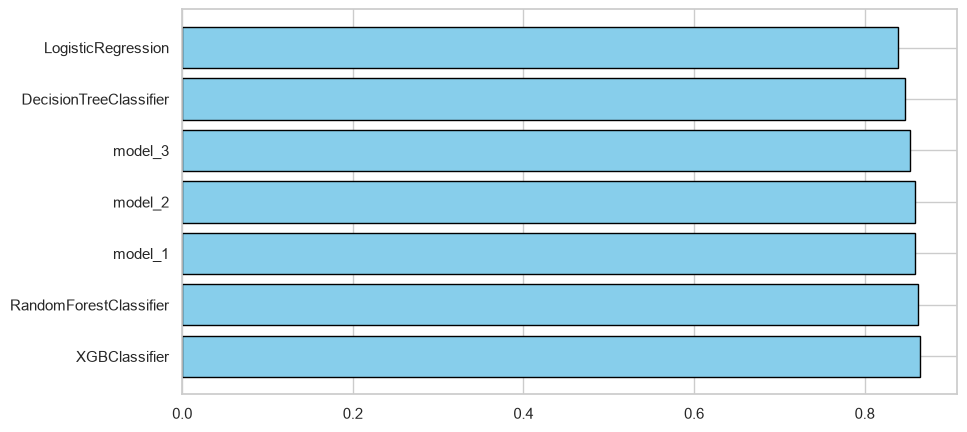

In [12]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

bars = plt.barh(
    results_df["model_name"], results_df["roc_auc"], color="skyblue", edgecolor="black"
)

In [13]:
y_predict_proba_cv = xgbc_model.predict_proba(x_cv)[:, 1]

for t in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
    y_pred_t = (y_predict_proba_cv >= t).astype(int)
    print(f'threshold={t}: recall={recall_score(y_cv, y_pred_t):.3f}, precision={precision_score(y_cv, y_pred_t):.3f}, f1={f1_score(y_cv, y_pred_t):.3f}')

threshold=0.15: recall=0.638, precision=0.366, f1=0.465
threshold=0.2: recall=0.568, precision=0.435, f1=0.493
threshold=0.25: recall=0.512, precision=0.482, f1=0.496
threshold=0.3: recall=0.451, precision=0.522, f1=0.484
threshold=0.35: recall=0.393, precision=0.572, f1=0.466
threshold=0.4: recall=0.333, precision=0.609, f1=0.431


In [14]:
y_predict_proba_test = xgbc_model.predict_proba(x_test)[:, 1]
y_predict_class_test = (y_predict_proba_test >= 0.2).astype(int)

test_auc = roc_auc_score(y_test, y_predict_proba_test)
test_f1 = f1_score(y_test, y_predict_class_test)

print(f'Test ROC-AUC: {test_auc:.4f}')
print(f'Test F1: {test_f1:.4f}')

Test ROC-AUC: 0.8616
Test F1: 0.4355


              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27877
           1       0.38      0.51      0.44      2002

    accuracy                           0.91     29879
   macro avg       0.67      0.73      0.69     29879
weighted avg       0.92      0.91      0.92     29879



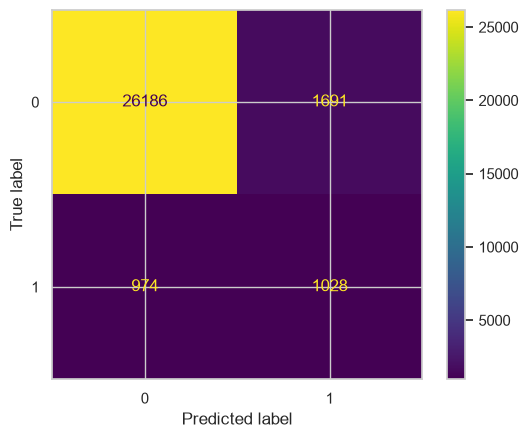

In [15]:
print(classification_report(y_test, y_predict_class_test))

cm = confusion_matrix(y_test, y_predict_class_test)
ConfusionMatrixDisplay(cm).plot()

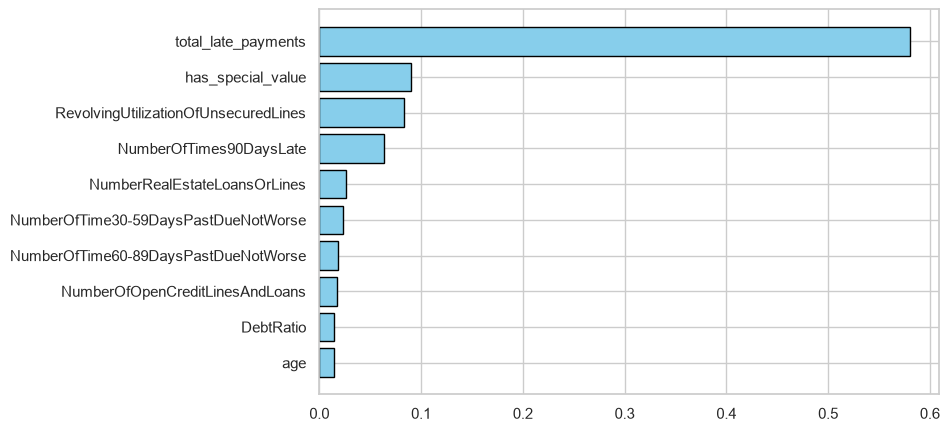

In [16]:
xgbc_features = xgbc_model.feature_importances_
feature_names = x_train.columns

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": xgbc_features})
importance_df = importance_df.sort_values(by="Importance", ascending=True)[12:]

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

bars = plt.barh(
    importance_df["Feature"], importance_df["Importance"], color="skyblue", edgecolor="black"
)

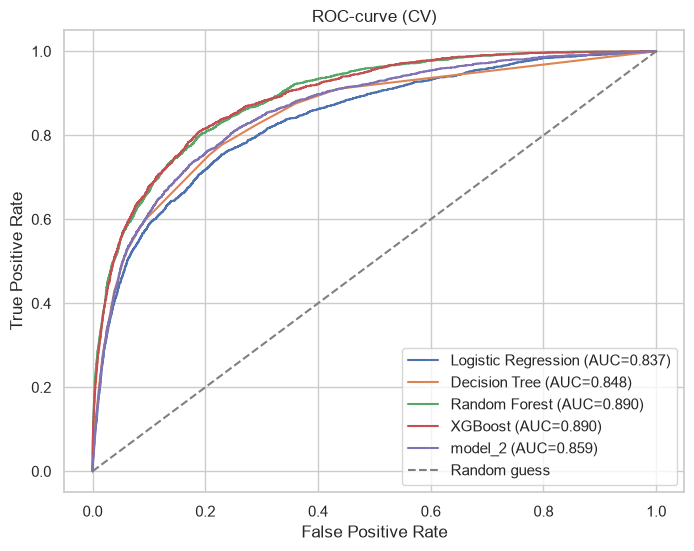

In [ ]:
plt.figure(figsize=(8, 6))

classical_models = {
    'Logistic Regression': (lr_model, x_cv_scaled), 
    'Decision Tree': (dt_model, x_cv),
    'Random Forest': (rf_model, x_cv),
    'XGBoost': (xgbc_model, x_cv),
}

for name, (model, x_cv_data) in classical_models.items():
    proba = model.predict_proba(x_cv_data.values)[:, 1]
    fpr, tpr, _ = roc_curve(y_cv, proba)
    auc = roc_auc_score(y_cv, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

best_nn = models_nn[1]  
logits_cv = best_nn.predict(x_cv_scaled, verbose=0).flatten()
proba_nn = tf.sigmoid(logits_cv).numpy()
fpr_nn, tpr_nn, _ = roc_curve(y_cv, proba_nn)
auc_nn = roc_auc_score(y_cv, proba_nn)
plt.plot(fpr_nn, tpr_nn, label=f'{best_nn.name} (AUC={auc_nn:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve (CV)')
plt.legend()
plt.show()